# 07 · Ranking features and validation boundaries

**OTTO · Multi-objective recommendation**

The observed-feature preparation is complete on the full frozen cache. This notebook presents its independently reconciled outputs, session-disjoint inner selection assignments, and verified resume behavior. **No learned ranker has been trained yet.**

The preceding retrieval experiment supports testing a neural candidate source. It does not establish the quality of a final top-20 ranking. The next experiment will materialize candidate features and fit objective-specific LambdaRank models.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from hashlib import sha256
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image

STARTED = time.perf_counter()
ROOT = Path.cwd() if (Path.cwd() / 'reports/metrics').is_dir() else Path.cwd().parent
METRICS = ROOT / 'reports/metrics'
FIGURES = ROOT / 'reports/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
report = json.loads((METRICS / 'ranking_features.json').read_text())
resume = json.loads((METRICS / 'ranking_features_resume.json').read_text())
audit = json.loads((METRICS / 'ranking_features_audit.json').read_text())
contract_path = METRICS / 'ranking_feature_contract.json'
contract = json.loads(contract_path.read_text())
assert report['status'] == audit['status'] == resume['status'] == 'passed'
assert report['input_id'] == resume['input_id'] == audit['input_id']
assert report['parts_sha256'] == resume['parts_sha256'] == audit['parts_sha256']
assert sha256(contract_path.read_bytes()).hexdigest() == report['contract_sha256']
assert report['contract_sha256'] == audit['feature_contract_sha256']
assert resume['reused_buckets'] == report['completed_buckets'] == audit['verified_buckets'] == 32
assert not any(audit['mismatches'].values())
print(datetime.now(timezone.utc).isoformat(), 'published_feature_evidence_verified')
print('Input identity:', report['input_id'])

2026-09-07T02:03:54.034716+00:00 published_feature_evidence_verified
Input identity: 82e8eac76c63d4d8a34b611bca0f3ae329623ff5cd80e18ca8bc238ddbd65795


In [2]:
cards = [('Observed sessions', f"{report['rows']['sessions']:,}"),
         ('Observed item rows', f"{report['rows']['items']:,}"),
         ('Evaluation queries', f"{report['rows']['queries']:,}"),
         ('Verified buckets', str(audit['verified_buckets']))]
html = '<div style="display:flex;flex-wrap:wrap;gap:12px;font-family:system-ui">'
for label, value in cards:
    html += f'<div style="padding:18px 24px;background:#f1f5f9;border-top:4px solid #2563eb;border-radius:8px"><div style="font-size:13px;color:#475569">{label}</div><div style="font-size:28px;color:#0f172a;font-weight:700">{value}</div></div>'
display(HTML(html + '</div>'))
display(pd.DataFrame(report['official_denominators']).set_index('objective').rename(columns={
    'true_items':'Distinct true items', 'recall_denominator':'Official capped denominator',
    'labeled_queries':'Queries with labels'}))

,Queries with labels,Official capped denominator,Distinct true items
objective,,,
carts,88042,165116,165973
clicks,501107,501107,501107
orders,45691,97828,98017


## Evaluation denominators remain complete

Official OTTO weighted Recall@20 is **0.10 × clicks + 0.30 × carts + 0.60 × orders**. For each objective, sum the per-session hits capped at 20 and divide by the sum of `min(20, number of distinct true items)`.

All three queries are retained for every session. A query with no labels contributes zero denominator; a labeled query with no retrieved positive remains a miss. Candidate membership and feature values are computed before targets are attached. The feature builder neither inserts positives nor samples away evaluation negatives.

These are evaluation inputs, **not model scores**.

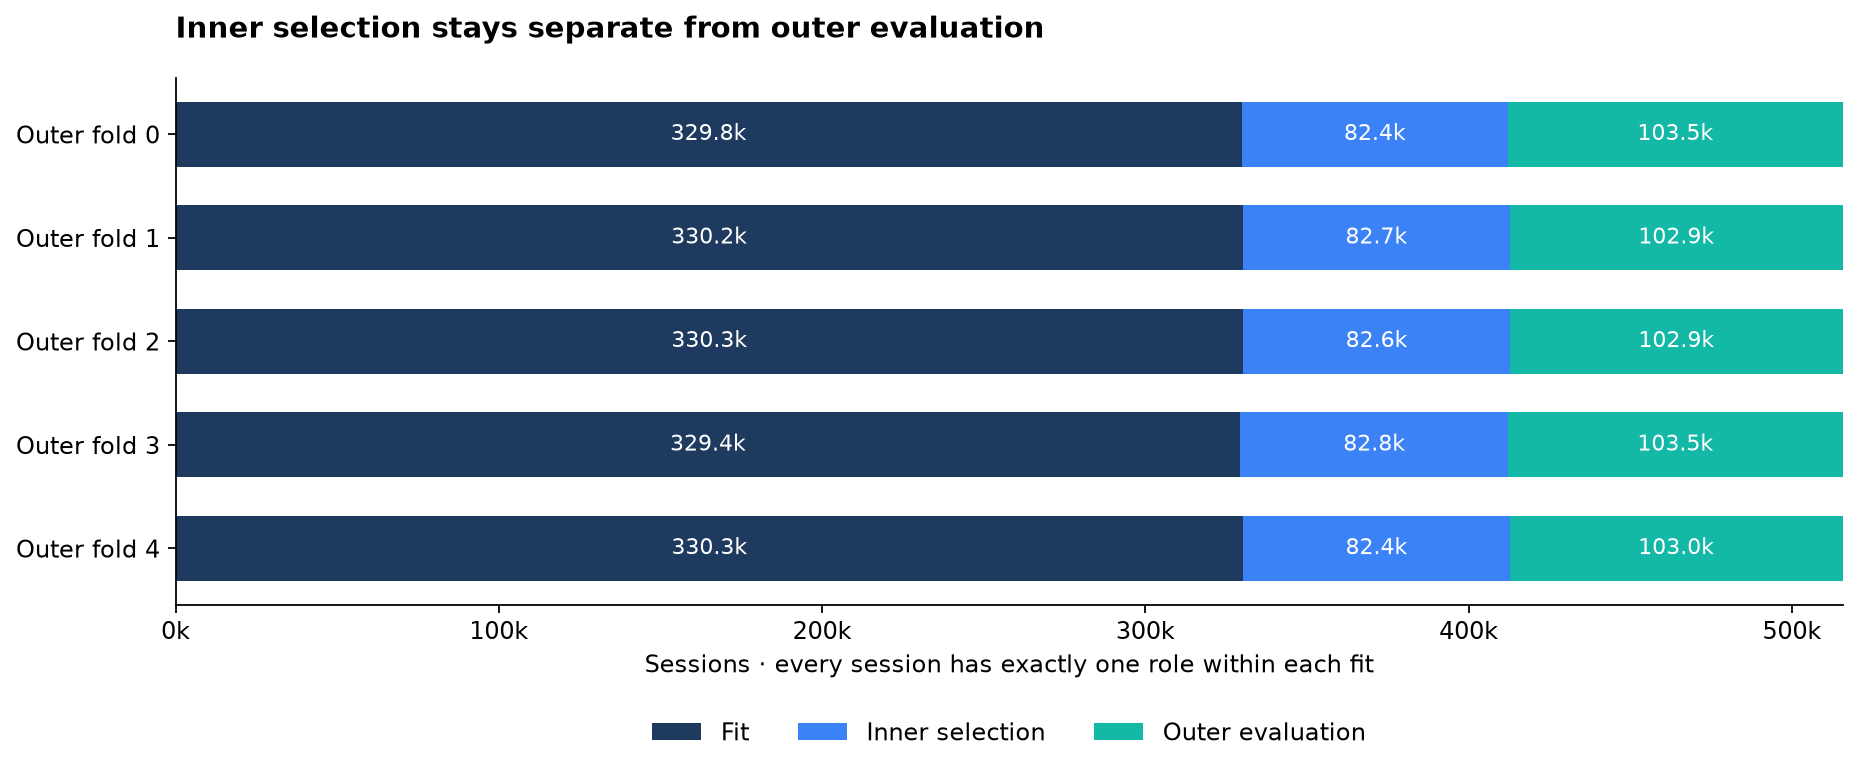

,fit,inner,outer
outer_fold,,,
0,329808,82426,103468
1,330159,82652,102891
2,330253,82583,102866
3,329422,82789,103491
4,330282,82434,102986


In [3]:
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.titleweight':'bold','figure.facecolor':'white'})
splits = pd.DataFrame(report['split_counts']).set_index('outer_fold')
fig, ax = plt.subplots(figsize=(11.5, 4.7), layout='constrained')
left = np.zeros(len(splits))
for key, color, title in [('fit','#1e3a5f','Fit'),('inner','#3b82f6','Inner selection'),('outer','#14b8a6','Outer evaluation')]:
    values = splits[key].to_numpy()
    ax.barh(splits.index, values, left=left, color=color, label=title, height=.63)
    for row, value, start in zip(splits.index, values, left):
        ax.text(start + value/2, row, f'{value/1000:.1f}k', va='center', ha='center', color='white', fontsize=10)
    left += values
ax.set_yticks(splits.index, [f'Outer fold {i}' for i in splits.index])
ax.invert_yaxis()
ax.set_xlabel('Sessions · every session has exactly one role within each fit')
ax.set_title('Inner selection stays separate from outer evaluation', loc='left', pad=18)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.18), ncol=3, frameon=False)
ax.set_xlim(0, report['rows']['sessions'])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
path = FIGURES / 'ranking_splits.png'
fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)
display(Image(filename=str(path)))
display(splits)

## What the split does—and what remains unverified

Each session keeps its original outer fold. An independent seeded hash assigns one of five inner partitions; among non-outer sessions, partition zero selects checkpoints and the remaining partitions fit the model. Assignments use neither labels nor row order.

These are **exploratory nested session splits within the previously used time window**. Fold 0 selected the existing neural checkpoint. New assignments cannot retroactively make that checkpoint an independent outer-fold model. The current label cache does not retain future-label timestamps, so this artifact does not certify an untouched temporal holdout.

Before training a ranker with learned retrieval scores, retriever training and checkpoint-selection provenance must also exclude the relevant evaluation labels. That source-provenance enforcement and full candidate materialization remain part of the next modeling milestone.

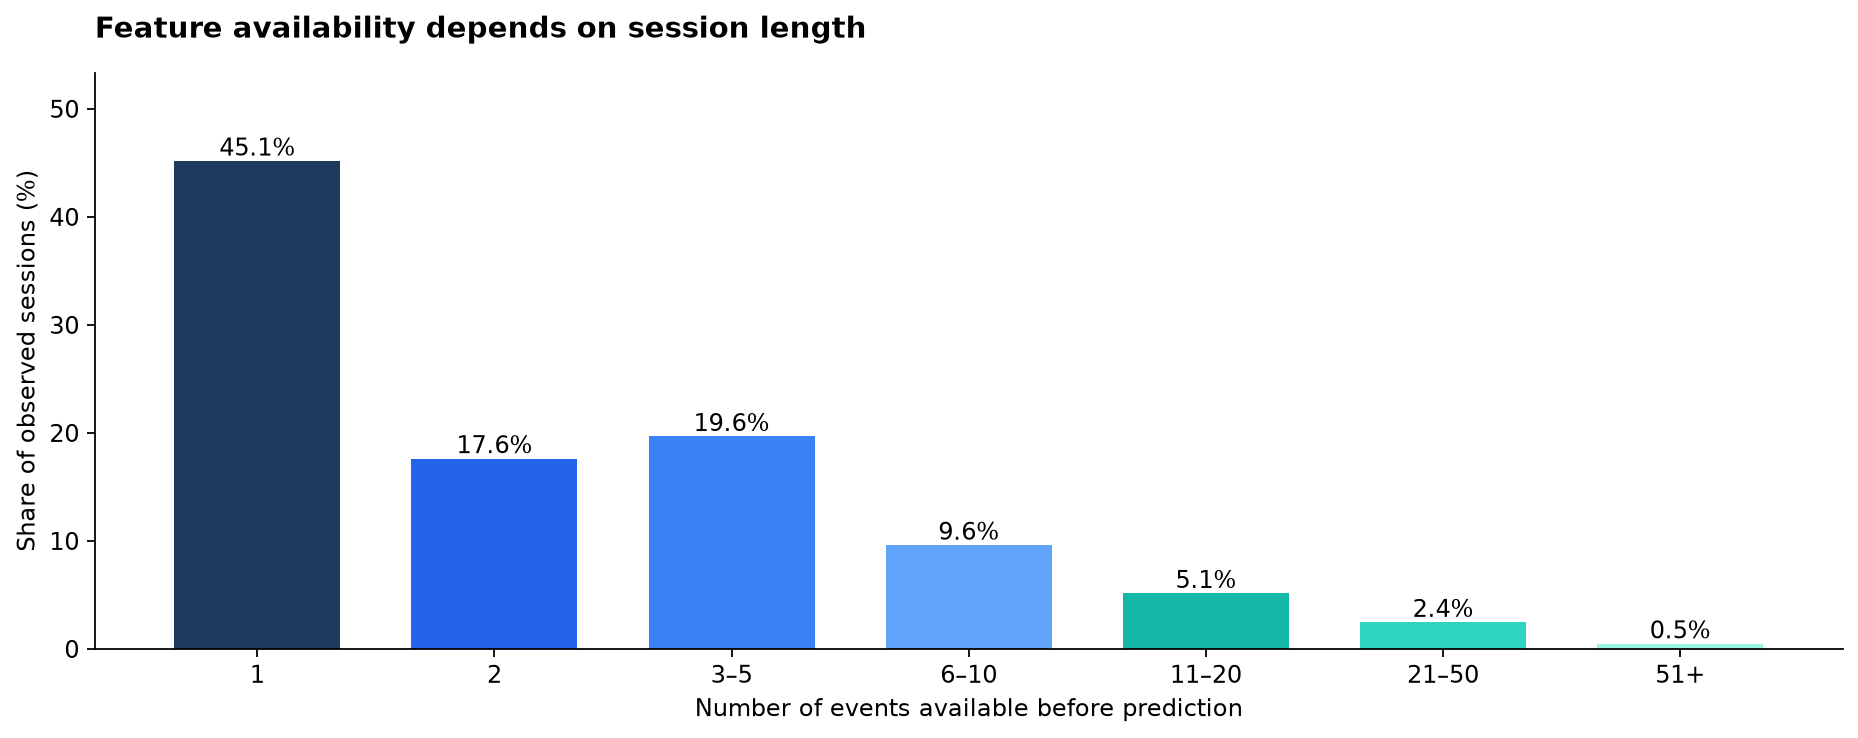

In [4]:
lengths = pd.DataFrame(audit['session_length_distribution'])
bins = [0, 1, 2, 5, 10, 20, 50, float('inf')]
names = ['1', '2', '3–5', '6–10', '11–20', '21–50', '51+']
lengths['prefix'] = pd.cut(lengths['observed_events'], bins=bins, labels=names)
counts = lengths.groupby('prefix', observed=False)['sessions'].sum()
percent = 100 * counts / counts.sum()
fig, ax = plt.subplots(figsize=(11.5, 4.5), layout='constrained')
ax.bar(names, percent, color=['#1e3a5f','#2563eb','#3b82f6','#60a5fa','#14b8a6','#2dd4bf','#99f6e4'], width=.7)
for i, value in enumerate(percent):
    ax.text(i, value + .5, f'{value:.1f}%', ha='center', fontsize=11)
ax.set_ylim(0, max(percent) * 1.18)
ax.set_ylabel('Share of observed sessions (%)')
ax.set_xlabel('Number of events available before prediction')
ax.set_title('Feature availability depends on session length', loc='left', pad=16)
path = FIGURES / 'ranking_session_lengths.png'
fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)
display(Image(filename=str(path)))
assert int(counts.sum()) == report['rows']['sessions']

In [5]:
feature_groups = pd.DataFrame([
    ['Source evidence', 'Presence, rank and score for revisit, time, type, buy, Item2Vec and two-tower', 'Missing rank/score = null; presence = 0'],
    ['Source agreement', 'Number of sources; sum of reciprocal ranks', 'Computed only from candidate outputs'],
    ['Session context', 'Event/type counts, unique items, duration', 'Observed prefix only; duration in milliseconds'],
    ['Item context', 'Repeat/type counts, last event type, age, event share', 'Unobserved counts/share = 0; age/type = null'],
    ['Evaluation metadata', 'Query identity, fold/inner assignments, targets, full denominators', 'Excluded from model feature columns'],
], columns=['Family','Contents','Meaning'])
display(feature_groups.style.hide(axis='index').set_properties(**{'text-align':'left','white-space':'normal'}))
timings = pd.DataFrame([
    ['Full preparation', report['attempt_elapsed_seconds'], 0],
    ['Verified resume', resume['attempt_elapsed_seconds'], resume['reused_buckets']],
    ['Independent DuckDB audit', audit['elapsed_seconds'], audit['verified_buckets']],
], columns=['Operation','Elapsed seconds','Buckets reused or verified'])
display(timings.style.hide(axis='index').format({'Elapsed seconds':'{:.3f}'}))
print(f"Persisted feature data: {report['bytes']/1024**2:.2f} MiB")
print('Independent reconciliation mismatches:', audit['mismatches'])

Persisted feature data: 28.53 MiB
Independent reconciliation mismatches: {'duplicate_keys': 0, 'items': 0, 'queries': 0, 'sessions': 0}


Family,Contents,Meaning
Source evidence,"Presence, rank and score for revisit, time, type, buy, Item2Vec and two-tower",Missing rank/score = null; presence = 0
Source agreement,Number of sources; sum of reciprocal ranks,Computed only from candidate outputs
Session context,"Event/type counts, unique items, duration",Observed prefix only; duration in milliseconds
Item context,"Repeat/type counts, last event type, age, event share",Unobserved counts/share = 0; age/type = null
Evaluation metadata,"Query identity, fold/inner assignments, targets, full denominators",Excluded from model feature columns


Operation,Elapsed seconds,Buckets reused or verified
Full preparation,10.279,0
Verified resume,2.623,32
Independent DuckDB audit,4.371,32


## Durability and the next experiment

The complete cache, contract, per-bucket checksum receipts and progress log are stored under the run's content identity in S3. A bucket's data is uploaded before its receipt. Restarts verify completed buckets and reuse them. Changed inputs, feature code or split configuration cannot silently reuse incompatible outputs.

The measured preparation timings above are from this CPU execution environment; they exclude initial input download and later publication to S3. The resume measurement checks the local saved cache. Fresh-workspace S3 recovery and interrupted transfers are covered by explicit integration tests using a simulated storage boundary.

Next: materialize the frozen baseline candidate pool, join the prepared features, and train objective-specific LightGBM LambdaRank with inner selection. Compare official weighted Recall@20, per-objective recall, NDCG@20, MRR@20, candidate coverage and paired uncertainty. Add neural candidates only with valid split provenance. Final full-test prediction, submission validation and Kaggle acceptance remain separate milestones.

[LightGBM query-group contract](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMRanker.html) · [Implementation and run instructions](../docs/RANKING.md)

In [6]:
print(datetime.now(timezone.utc).isoformat(), 'notebook_complete',
      f'elapsed_seconds={time.perf_counter()-STARTED:.3f}')
print('Observed feature cache: complete and independently reconciled')
print('Learned ranker evaluation: pending | Kaggle submission: pending')

2026-09-07T02:03:54.557890+00:00 notebook_complete elapsed_seconds=0.524
Observed feature cache: complete and independently reconciled
Learned ranker evaluation: pending | Kaggle submission: pending
